In [10]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [11]:
stocks = [
    "ADANIENT.NS",
    "ADANIPORTS.NS",
    "APOLLOHOSP.NS",
    "ASIANPAINT.NS",
    "AXISBANK.NS",
    "BAJAJ-AUTO.NS",
    "BAJFINANCE.NS",
    "BEL.NS",
    "BHARTIARTL.NS",
    "CIPLA.NS",
    "COALINDIA.NS",
    "DRREDDY.NS",
    "EICHERMOT.NS",
    "ETERNAL.NS",   # formerly Zomato
    "GRASIM.NS",
    "HCLTECH.NS",
    "HDFCBANK.NS",
    "HDFCLIFE.NS",
    "HEROMOTOCO.NS",
    "HINDALCO.NS",
    "HINDUNILVR.NS",
    "ICICIBANK.NS",
    "INDUSINDBK.NS",
    "INFY.NS",
    "ITC.NS",
    "JIOFIN.NS",
    "JSWSTEEL.NS",
    "KOTAKBANK.NS",
    "LT.NS",
    "M&M.NS",
    "MARUTI.NS",
    "NESTLEIND.NS",
    "NTPC.NS",
    "ONGC.NS",
    "POWERGRID.NS",
    "RELIANCE.NS",
    "SBILIFE.NS",
    "SBIN.NS",
    "SHRIRAMFIN.NS",
    "SUNPHARMA.NS",
    "TATACONSUM.NS",
    "TATAMOTORS.NS",
    "TATASTEEL.NS",
    "TCS.NS",
    "TECHM.NS",
    "TITAN.NS",
    "TRENT.NS",
    "ULTRACEMCO.NS",
    "WIPRO.NS"
]




In [12]:
data = yf.download(
    stocks,
    start="2020-01-01",
   
    auto_adjust=True,
    progress=False
)["Close"]

data.head()

HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
$TATAMOTORS.NS: possibly delisted; no timezone found

1 Failed download:
['TATAMOTORS.NS']: possibly delisted; no timezone found


Ticker,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJFINANCE.NS,BEL.NS,BHARTIARTL.NS,CIPLA.NS,...,SUNPHARMA.NS,TATACONSUM.NS,TATAMOTORS.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,TRENT.NS,ULTRACEMCO.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-01,205.794525,361.062622,1403.106934,1705.415283,745.586914,2599.727539,413.532135,29.713722,433.316467,449.420288,...,406.074005,306.714355,NaN,38.457081,1841.149658,602.617493,1132.704834,526.402710,3942.765625,113.709190
2020-01-02,209.111374,366.320984,1470.294189,1702.990356,753.802612,2575.711914,414.973694,30.603796,435.132690,447.153809,...,406.681793,306.240814,NaN,39.862995,1832.697998,605.740845,1133.538452,538.030823,4117.158203,113.984619
2020-01-03,206.240051,365.699554,1461.883301,1665.661743,739.860840,2535.314453,409.833008,29.951082,435.037109,443.801331,...,415.704590,301.363342,NaN,39.768444,1869.222168,612.897034,1117.942017,532.614441,4092.329102,115.269989
2020-01-06,197.576584,363.500580,1438.667969,1623.578125,720.242737,2506.924072,390.604340,28.764307,429.827393,440.779419,...,411.356812,295.586090,NaN,38.909275,1869.052002,609.180603,1136.481323,526.700806,4032.096191,115.751999
2020-01-07,202.032059,367.898529,1454.603882,1639.983765,722.732361,2507.171875,391.674500,28.586296,425.477936,442.526459,...,417.387634,298.237915,NaN,39.143597,1873.639771,614.478394,1137.805420,529.682495,4114.539551,117.152122


In [13]:
returns = data.pct_change()
momentum = data.pct_change(63)

rebalance_dates = momentum.index[63::63]

In [14]:
print(len(rebalance_dates))
print(rebalance_dates[:5])

25
DatetimeIndex(['2020-04-01', '2020-07-07', '2020-10-05', '2021-01-04',
               '2021-04-07'],
              dtype='datetime64[s]', name='Date', freq=None)


In [15]:
portfolio_returns = []

for i in range(len(rebalance_dates) - 1):

    current_date = rebalance_dates[i]
    next_date = rebalance_dates[i + 1]

    ranked = (
        momentum.loc[current_date]
        .dropna()
        .sort_values(ascending=False)
    )

    top5 = ranked.index[:5]

    period_returns = (
        returns.loc[current_date:next_date, top5]
        .iloc[1:]
        .mean(axis=1)
    )

    portfolio_returns.append(period_returns)


portfolio_returns = pd.concat(portfolio_returns)



In [16]:
portfolio_curve = (
    1 + portfolio_returns).cumprod()

benchmark_returns = (
    returns.mean(axis=1)
)

benchmark_curve = (
    1 + benchmark_returns
).cumprod()

In [17]:
portfolio_return = (
    portfolio_curve.iloc[-1] - 1
) * 100

benchmark_return = (
    benchmark_curve.iloc[-1] - 1
) * 100

print(
    "Momentum Portfolio:",
    round(portfolio_return,2),
    "%"
)

print(
    "Equal Weight Buy Hold:",
    round(benchmark_return,2),
    "%"
)

cagr = portfolio_curve.iloc[-1] ** (252/len(portfolio_curve)) - 1

print("CAGR:", round(cagr*100,2), "%")

sharpe = (
    portfolio_returns.mean()
    /
    portfolio_returns.std()
) * np.sqrt(252)

print(
    "Sharpe:",
    round(sharpe,2)
)

running_max = portfolio_curve.cummax()

drawdown = (
    portfolio_curve
    /
    running_max
    - 1
)

print(
    "Max Drawdown:",
    round(drawdown.min()*100,2),
    "%"
)

Momentum Portfolio: 740.24 %
Equal Weight Buy Hold: 262.41 %
CAGR: 42.58 %
Sharpe: 1.81
Max Drawdown: -18.85 %


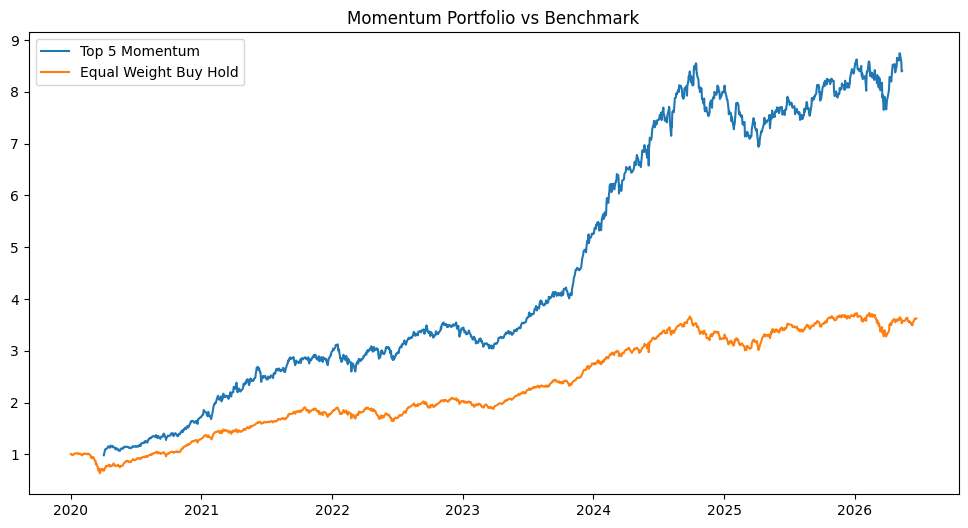

In [18]:
plt.figure(figsize=(12,6))

plt.plot(
    portfolio_curve,
    label="Top 5 Momentum"
)

plt.plot(
    benchmark_curve,
    label="Equal Weight Buy Hold"
)

plt.legend()

plt.title(
    "Momentum Portfolio vs Benchmark"
)

plt.show()